In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as nc

In [11]:
#read data
path='../.data/GRIDMET/'
ds0 = xr.open_dataset(path+"tmmx_2000.nc")
ds0

<xarray.Dataset> Size: 2GB
Dimensions:          (day: 366, lat: 585, lon: 1386, crs: 1)
Coordinates:
  * day              (day) datetime64[ns] 3kB 2000-01-01 ... 2000-12-31
  * lat              (lat) float64 5kB 49.4 49.36 49.32 ... 25.15 25.11 25.07
  * lon              (lon) float64 11kB -124.8 -124.7 -124.7 ... -67.1 -67.06
  * crs              (crs) uint16 2B 3
Data variables:
    air_temperature  (day, lat, lon) float64 2GB ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 July 2019
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

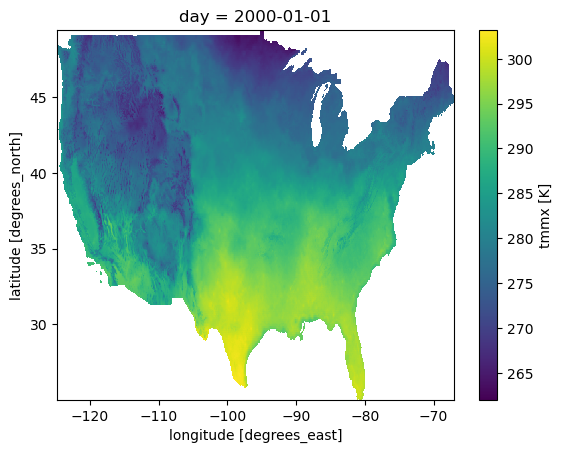

In [5]:
ds0.air_temperature.isel(day=0).plot()

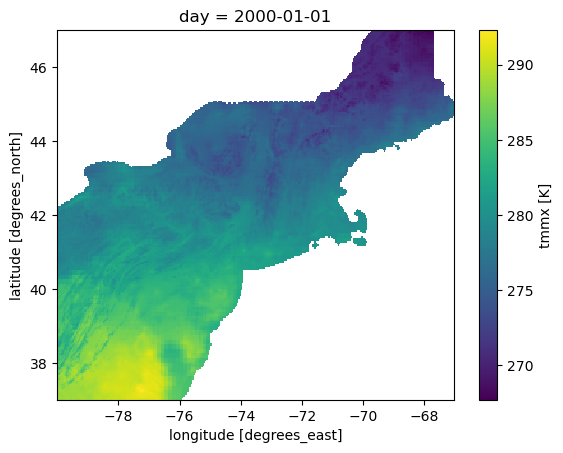

In [6]:
#slice the data to Northeastern US
sub = ds0.sel(
    lat=slice(47, 37),   # reversed because lat is descending
    lon=slice(-80, -60)
)

sub.air_temperature.isel(day=0).plot()

In [13]:
import xarray as xr
import glob
import os

in_path = "../.data/GRIDMET/"
out_path = "../.data/GRIDMET/gridmet_4km_jja_ne/"

os.makedirs(out_path, exist_ok=True)

files = sorted(glob.glob(in_path + "tmmx_*.nc"))

for f in files:
    print("Processing:", os.path.basename(f))
    
    ds = xr.open_dataset(f)

    # slice region
    ds_sub = ds.sel(
        lat=slice(47, 37),   # descending latitude
        lon=slice(-80, -60)
    )

    # keep only JJA
    ds_jja = ds_sub.where(ds_sub.day.dt.month.isin([6, 7, 8]), drop=True)

    # optional: remove attrs that may conflict later
    ds_jja.attrs = {}

    # output filename
    out_file = os.path.join(out_path, os.path.basename(f).replace(".nc", "_JJA_NE.nc"))

    # save
    ds_jja.to_netcdf(out_file)

    # close datasets
    ds.close()
    ds_sub.close()
    ds_jja.close()

print("Done.")

Processing: tmmx_2000.nc
Processing: tmmx_2001.nc
Processing: tmmx_2002.nc
Processing: tmmx_2003.nc
Processing: tmmx_2004.nc
Processing: tmmx_2005.nc
Processing: tmmx_2006.nc
Processing: tmmx_2007.nc
Processing: tmmx_2008.nc
Processing: tmmx_2009.nc
Processing: tmmx_2010.nc
Processing: tmmx_2011.nc
Processing: tmmx_2012.nc
Processing: tmmx_2013.nc
Processing: tmmx_2014.nc
Processing: tmmx_2015.nc
Processing: tmmx_2016.nc
Processing: tmmx_2017.nc
Processing: tmmx_2018.nc
Processing: tmmx_2019.nc
Processing: tmmx_2020.nc
Processing: tmmx_2021.nc
Processing: tmmx_2022.nc
Processing: tmmx_2023.nc
Processing: tmmx_2024.nc
Processing: tmmx_2025.nc
Done.


In [14]:
import xarray as xr
import glob

out_path = "../.data/GRIDMET/gridmet_4km_jja_ne/"
files_small = sorted(glob.glob(out_path + "tmmx_*_JJA_NE.nc"))

datasets = [xr.open_dataset(f) for f in files_small]
ds_all = xr.concat(datasets, dim="day").sortby("day")

ds_all

<xarray.Dataset> Size: 1GB
Dimensions:          (day: 2392, lat: 240, lon: 311, crs: 1)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon              (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
  * crs              (crs) uint16 2B 3
Data variables:
    air_temperature  (day, lat, lon) float64 1GB nan nan nan nan ... nan nan nan

In [15]:
#save as a single netCDF file
save_path = "../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc"
ds_all.to_netcdf(save_path)